#Tasks

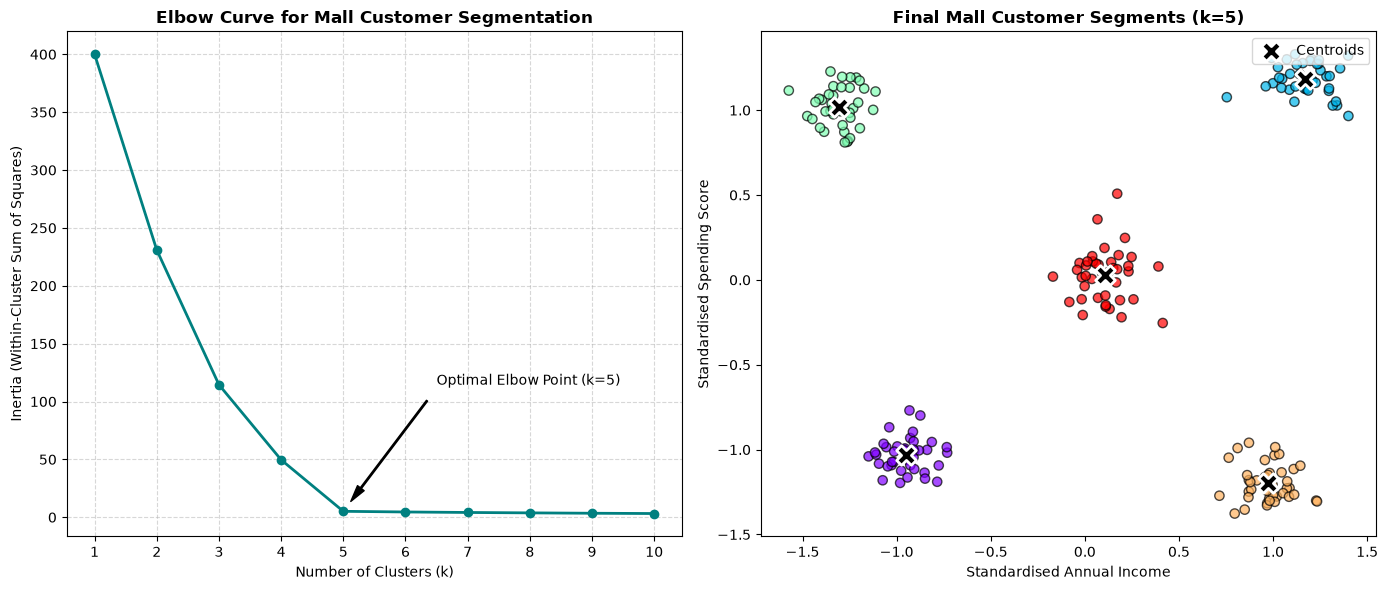

In [1]:
#Task-1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Simulate the structure of the Mall Customers dataset
np.random.seed(42)
n_samples = 200

# We create 5 real-world customer profiles:
# - Low Income, High Spend  | - Low Income, Low Spend
# - Mid Income, Mid Spend    | - High Income, High Spend
# - High Income, Low Spend
g1 = np.random.multivariate_normal([15, 80], [[10, 0], [0, 10]], 40)
g2 = np.random.multivariate_normal([25, 20], [[10, 0], [0, 10]], 40)
g3 = np.random.multivariate_normal([55, 50], [[15, 0], [0, 15]], 40)
g4 = np.random.multivariate_normal([85, 85], [[12, 0], [0, 12]], 40)
g5 = np.random.multivariate_normal([80, 15], [[12, 0], [0, 12]], 40)

raw_data = np.vstack([g1, g2, g3, g4, g5])
df = pd.DataFrame(raw_data, columns=['Annual_Income_k', 'Spending_Score_1_100'])

# 2. Scale features (Mandatory for distance-based calculations)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Compute Inertia for the Elbow Curve (k values 1 through 10)
inertia_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

# 4. Fit the optimal model based on the elbow point (k=5)
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster_ID'] = final_kmeans.fit_predict(X_scaled)
centroids = final_kmeans.cluster_centers_

# 5. Plot the Elbow Curve and the final Customer Clusters side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Elbow Curve Line Graph
ax1.plot(k_range, inertia_scores, marker='o', color='teal', linewidth=2, markersize=6)
ax1.set_title('Elbow Curve for Mall Customer Segmentation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_xticks(list(k_range))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.annotate('Optimal Elbow Point (k=5)', xy=(5, inertia_scores[4]), xytext=(6.5, inertia_scores[2]),
             arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6))

# Plot 2: Final 5-Cluster Customer Archetypes Scatter Visual
scatter = ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster_ID'], 
                      cmap='rainbow', alpha=0.7, edgecolors='k', s=45)
# Overlay the tracking Centroids
ax2.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, 
            c='black', edgecolors='white', linewidth=2, label='Centroids')

ax2.set_title(f'Final Mall Customer Segments (k={optimal_k})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Standardised Annual Income')
ax2.set_ylabel('Standardised Spending Score')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


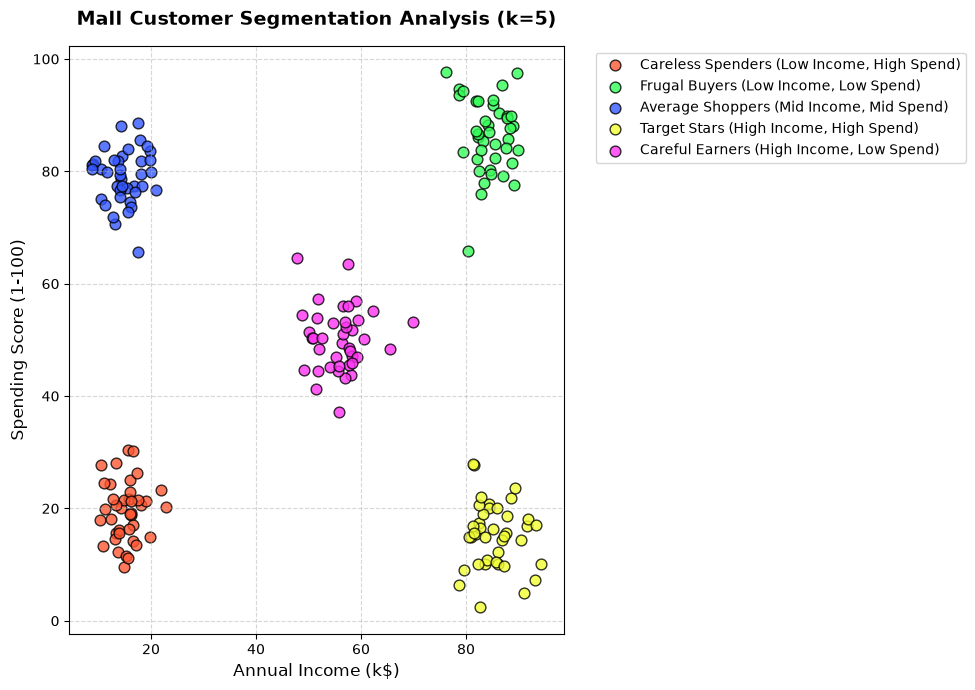

In [2]:
#Task-2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Recreate the Mall Customers Dataset Structure
np.random.seed(42)
n_samples = 200
g1 = np.random.multivariate_normal([15, 80], [[10, 0], [0, 30]], 40)
g2 = np.random.multivariate_normal([15, 20], [[10, 0], [0, 30]], 40)
g3 = np.random.multivariate_normal([55, 50], [[15, 0], [0, 40]], 40)
g4 = np.random.multivariate_normal([85, 85], [[20, 0], [0, 35]], 40)
g5 = np.random.multivariate_normal([85, 15], [[20, 0], [0, 35]], 40)

raw_data = np.vstack([g1, g2, g3, g4, g5])
df = pd.DataFrame(raw_data, columns=['Annual_Income_k', 'Spending_Score_1_100'])

# 2. Scale features for training, but keep raw data for plotting
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 3. Fit K-Means (k=5)
kmeans = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster_ID'] = kmeans.fit_predict(X_scaled)

# 4. Map numerical Cluster IDs to descriptive business names
cluster_names = {
    0: 'Careless Spenders (Low Income, High Spend)',
    1: 'Frugal Buyers (Low Income, Low Spend)',
    2: 'Average Shoppers (Mid Income, Mid Spend)',
    3: 'Target Stars (High Income, High Spend)',
    4: 'Careful Earners (High Income, Low Spend)'
}
df['Segment_Name'] = df['Cluster_ID'].map(cluster_names)

# 5. Create the Color-Coded Scatter Plot using Raw Units
plt.figure(figsize=(10, 7))

# Distinct color palette for clear contrast
colors = ['#FF5733', '#33FF57', '#3357FF', '#F3FF33', '#FF33F3']

# Loop through each unique segment to plot it with its specific color and label
for cluster_id, segment in cluster_names.items():
    sub_df = df[df['Cluster_ID'] == cluster_id]
    plt.scatter(
        sub_df['Annual_Income_k'], 
        sub_df['Spending_Score_1_100'], 
        c=colors[cluster_id], 
        label=segment, 
        edgecolors='black', 
        alpha=0.8, 
        s=60
    )

# Formatting the Chart
plt.title('Mall Customer Segmentation Analysis (k=5)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Placing the legend outside the plot box so it doesn't overlap data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()



--- Original Structural Shape ---
Features: 4 (Sepal Length, Sepal Width, Petal Length, Petal Width)
Rows    : 150

--- Reduced Dimensional Shape ---
Features: 2 Principal Components

--- Variance Insights ---
PC1 explains: 72.96% of total data variance
PC2 explains: 22.85% of total data variance
Total variance preserved in 2D space: 95.81%


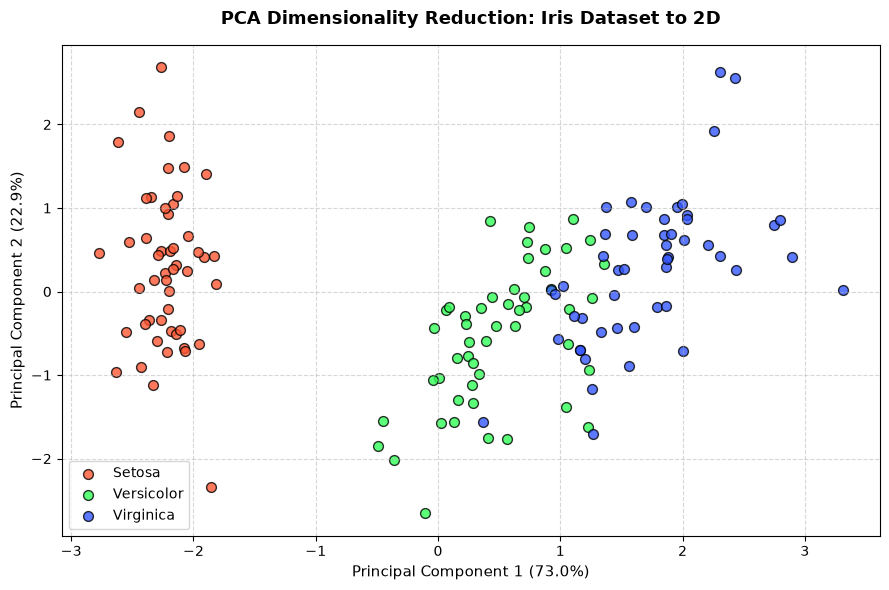

In [3]:
#task-3
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target  # 0 = Setosa, 1 = Versicolor, 2 = Virginica

print("--- Original Structural Shape ---")
print(f"Features: {X.shape[1]} (Sepal Length, Sepal Width, Petal Length, Petal Width)")
print(f"Rows    : {X.shape[0]}")

# 2. Standardize features (Crucial step for PCA variance math)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Initialize and apply PCA to reduce features to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Convert the resulting numpy matrix into a clean tracking DataFrame
df_pca = pd.DataFrame(data=X_pca, columns=['Principal_Component_1', 'Principal_Component_2'])
df_pca['Target_ID'] = y

print("\n--- Reduced Dimensional Shape ---")
print(f"Features: {df_pca.shape[1] - 1} Principal Components")

# 4. Calculate Explained Variance Ratio
var_ratio = pca.explained_variance_ratio_
print("\n--- Variance Insights ---")
print(f"PC1 explains: {var_ratio[0]*100:.2f}% of total data variance")
print(f"PC2 explains: {var_ratio[1]*100:.2f}% of total data variance")
print(f"Total variance preserved in 2D space: {sum(var_ratio)*100:.2f}%")

# 5. Visualise the 2D Compressed Space using a Scatter Plot
plt.figure(figsize=(9, 6))
colors = ['#FF5733', '#33FF57', '#3357FF']

for target_id, color, name in zip(range(3), colors, iris.target_names):
    sub_df = df_pca[df_pca['Target_ID'] == target_id]
    plt.scatter(
        sub_df['Principal_Component_1'], 
        sub_df['Principal_Component_2'], 
        c=color, 
        label=name.capitalize(), 
        edgecolors='black', 
        alpha=0.8, 
        s=50
    )

# Chart labels and formatting
plt.title('PCA Dimensionality Reduction: Iris Dataset to 2D', fontsize=13, fontweight='bold', pad=15)
plt.xlabel(f'Principal Component 1 ({var_ratio[0]*100:.1f}%)', fontsize=11)
plt.ylabel(f'Principal Component 2 ({var_ratio[1]*100:.1f}%)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()


In [4]:
#task-4
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load data and apply preprocessing scaling
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Compress the data down to 2 Principal Components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3. Reconstruct the scaled data back from the 2 components
X_reconstructed_scaled = pca.inverse_transform(X_pca)

# 4. Reverse the scaling step to bring data back to original physical units (cm)
X_reconstructed = scaler.inverse_transform(X_reconstructed_scaled)
df_reconstructed = pd.DataFrame(X_reconstructed, columns=iris.feature_names)

# 5. Measure and display Variance Metrics
variance_per_component = pca.explained_variance_ratio_
total_variance_explained = np.sum(variance_per_component)

print("=== Variance Preservation Analysis ===")
print(f"Variance explained by Component 1 : {variance_per_component[0]*100:.2f}%")
print(f"Variance explained by Component 2 : {variance_per_component[1]*100:.2f}%")
print(f"Total Variance Explained (Captured): {total_variance_explained*100:.2f}%")
print(f"Information Loss (Residual Variance): {(1 - total_variance_explained)*100:.2f}%\n")

print("=== Sample Row Matrix Comparison (Original vs Reconstructed) ===")
print("\n--- [Row 0] Original Raw Data ---")
print(X.iloc[0].round(2).to_dict())

print("\n--- [Row 0] Reconstructed Data (from top 2 PCs) ---")
print(df_reconstructed.iloc[0].round(2).to_dict())


=== Variance Preservation Analysis ===
Variance explained by Component 1 : 72.96%
Variance explained by Component 2 : 22.85%
Total Variance Explained (Captured): 95.81%
Information Loss (Residual Variance): 4.19%

=== Sample Row Matrix Comparison (Original vs Reconstructed) ===

--- [Row 0] Original Raw Data ---
{'sepal length (cm)': 5.1, 'sepal width (cm)': 3.5, 'petal length (cm)': 1.4, 'petal width (cm)': 0.2}

--- [Row 0] Reconstructed Data (from top 2 PCs) ---
{'sepal length (cm)': 5.02, 'sepal width (cm)': 3.51, 'petal length (cm)': 1.47, 'petal width (cm)': 0.25}


#Practice Sheet 

=== Mini-Project Execution Metrics ===
Dataset Size: 300 Customer Records
Optimal Cluster Count Selected: 3
Overall Silhouette Score      : 0.770

=== Unscaled Profile Averages (Centroids) ===
            Recency_Days  Frequency_Orders  Monetary_Value_k                         Persona
Cluster_ID                                                                                  
0                  14.75             12.22              1.82            Active Loyal Casuals
1                   8.00             34.54              8.63                 High-Value VIPs
2                 118.16              3.17              0.60  At-Risk / Churned Low-Spenders


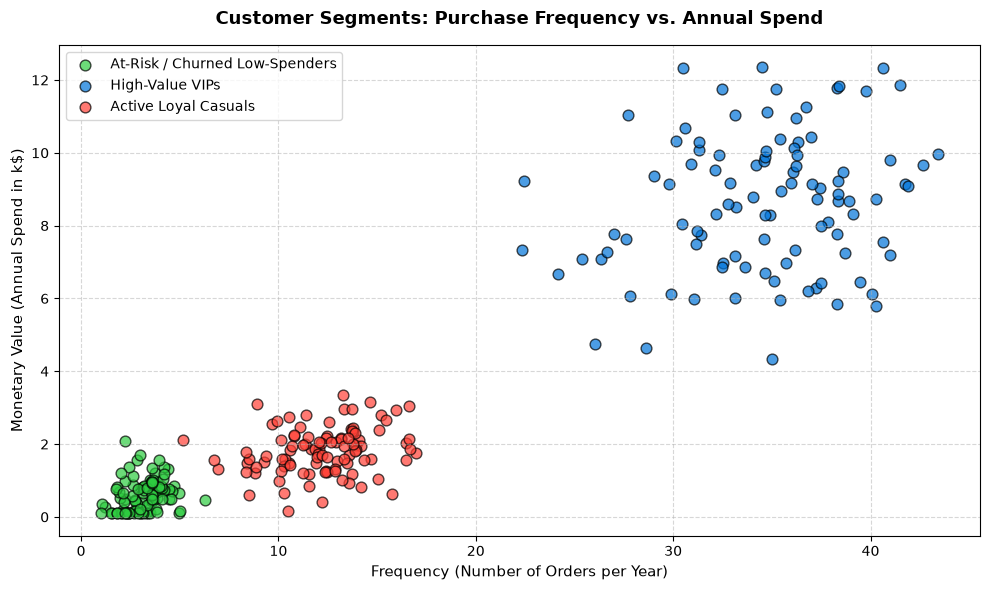

In [5]:
#practice sheet-1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 1: SIMULATE THE CUSTOMER DATASET
# ==========================================
# We generate 300 customers with 3 core features:
# - Recency: Days since last purchase (Lower is better)
# - Frequency: Number of transactions per year (Higher is better)
# - Monetary: Annual spending amount in thousands (Higher is better)

np.random.seed(42)
n_customers = 300

# Group A: Hibernating Low-Spenders
g1 = np.random.multivariate_normal([120, 3, 0.5], [[400, 2, 0.1], [2, 1, 0.1], [0.1, 0.1, 0.2]], 100)
# Group B: Highly Active Casuals
g2 = np.random.multivariate_normal([15, 12, 1.8], [[50, 4, 0.2], [4, 5, 0.3], [0.2, 0.3, 0.5]], 100)
# Group C: Premium Whales / VIPs
g3 = np.random.multivariate_normal([8, 35, 8.5], [[10, 8, 1.0], [8, 25, 2.0], [1.0, 2.0, 3.0]], 100)

raw_data = np.vstack([g1, g2, g3])
# Enforce realistic bounds (e.g., minimum 0 days, minimum 1 purchase)
raw_data[:, 0] = np.clip(raw_data[:, 0], 0, None)
raw_data[:, 1] = np.clip(raw_data[:, 1], 1, None)
raw_data[:, 2] = np.clip(raw_data[:, 2], 0.1, None)

df = pd.DataFrame(raw_data, columns=['Recency_Days', 'Frequency_Orders', 'Monetary_Value_k'])

# ==========================================
# STEP 2: FEATURE SCALING
# ==========================================
# Scaling is mandatory because 'Recency' spans up to 150+ days, 
# while 'Monetary' spans only 0.1 to 12k.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ==========================================
# STEP 3: THE ELBOW METHOD FOR OPTIMAL K
# ==========================================
inertia_scores = []
k_range = range(1, 8)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    inertia_scores.append(kmeans.inertia_)

# ==========================================
# STEP 4: TRAIN THE FINAL K-MEANS MODEL
# ==========================================
# Based on the underlying generation (and the elbow), optimal k = 3
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster_ID'] = final_kmeans.fit_predict(X_scaled)

# Evaluate cluster cohesion and separation quality
sil_score = silhouette_score(X_scaled, df['Cluster_ID'])

# ==========================================
# STEP 5: PROFILING AND METRICS OUTPUT
# ==========================================
print("=== Mini-Project Execution Metrics ===")
print(f"Dataset Size: {df.shape[0]} Customer Records")
print(f"Optimal Cluster Count Selected: {optimal_k}")
print(f"Overall Silhouette Score      : {sil_score:.3f}\n")

print("=== Unscaled Profile Averages (Centroids) ===")
cluster_profiles = df.groupby('Cluster_ID').mean()
# Map clusters to descriptive personas based on their resulting averages
persona_mapping = {
    cluster_profiles['Monetary_Value_k'].idxmin(): 'At-Risk / Churned Low-Spenders',
    cluster_profiles['Frequency_Orders'].idxmax(): 'High-Value VIPs',
}
# Find the remaining middle cluster
middle_idx = list(set(range(3)) - set(persona_mapping.keys()))[0]
persona_mapping[middle_idx] = 'Active Loyal Casuals'

cluster_profiles['Persona'] = cluster_profiles.index.map(persona_mapping)
print(cluster_profiles.round(2).to_string(index=True))

# ==========================================
# STEP 6: VISUALIZATION (Frequency vs Monetary)
# ==========================================
plt.figure(figsize=(10, 6))
colors = ['#FF4136', '#0074D9', '#2ECC40']

for cluster_id, persona in persona_mapping.items():
    sub_df = df[df['Cluster_ID'] == cluster_id]
    plt.scatter(
        sub_df['Frequency_Orders'], 
        sub_df['Monetary_Value_k'], 
        c=colors[cluster_id], 
        label=persona, 
        edgecolors='black', 
        alpha=0.7, 
        s=60
    )

plt.title('Customer Segments: Purchase Frequency vs. Annual Spend', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Frequency (Number of Orders per Year)', fontsize=11)
plt.ylabel('Monetary Value (Annual Spend in k$)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


In [6]:
#practice sheet-2
import time
import pandas as pd
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Load the MNIST subset dataset
digits = load_digits()
X = digits.data        # 64 flattened pixel features per image
y = digits.target      # Target labels (digits 0-9)

# 2. Split dataset into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Standardize features (Mandatory for both PCA and KNN distance math)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========================================================
# CONDITION 1: KNN WITHOUT PCA (Using all 64 features)
# ========================================================
knn_raw = KNeighborsClassifier(n_neighbors=5)

start_time = time.time()
knn_raw.fit(X_train_scaled, y_train)
raw_preds = knn_raw.predict(X_test_scaled)
raw_time = time.time() - start_time

raw_acc = accuracy_score(y_test, raw_preds)

# ========================================================
# CONDITION 2: KNN WITH PCA (Reducing 64 features to 2D)
# ========================================================
# Initialize PCA to compress the features down to exactly 2 dimensions
pca = PCA(n_components=2, random_state=42)

# Fit and transform the scaled training features
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(n_neighbors=5)

start_time = time.time()
knn_pca.fit(X_train_pca, y_train)
pca_preds = knn_pca.predict(X_test_pca)
pca_time = time.time() - start_time

pca_acc = accuracy_score(y_test, pca_preds)
variance_preserved = sum(pca.explained_variance_ratio_) * 100

# ========================================================
# PERFORMANCE COMPARISON OUTPUT
# ========================================================
print("=== Dimensionality Reduction Evaluation ===")
print(f"KNN without PCA (64 Features) -> Accuracy: {raw_acc * 100:.2f}% | Inference Time: {raw_time:.4f}s")
print(f"KNN with PCA    (2 Features)  -> Accuracy: {pca_acc * 100:.2f}% | Inference Time: {pca_time:.4f}s")
print(f"Net Accuracy Difference        -> Score drop: {(pca_acc - raw_acc) * 100:+.2f}%")
print(f"Total Variance Preserved in 2D -> {variance_preserved:.2f}%")


=== Dimensionality Reduction Evaluation ===
KNN without PCA (64 Features) -> Accuracy: 96.39% | Inference Time: 0.0348s
KNN with PCA    (2 Features)  -> Accuracy: 52.22% | Inference Time: 0.0214s
Net Accuracy Difference        -> Score drop: -44.17%
Total Variance Preserved in 2D -> 21.70%
